# 01 — Análise exploratória: vendas do e-commerce (nov/2025 a jun/2026)

**Perguntas do case:** preço médio de venda, potencial por dia da semana e flutuação ao longo do dia.
**Como ler:** cada seção traz a pergunta, o gráfico e a leitura de negócio. A lógica fica em `src/eda.py` e `src/data_loader.py`; o notebook só orquestra.

In [1]:
# Setup (Colab): descomente, ajuste a URL do repositório e envie o CSV para data/raw/vendas.csv
# !git clone https://github.com/<usuario>/<repo>.git && %cd <repo>
# !pip install -q -r requirements.txt
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from IPython.display import Image, display
from src import eda
from src.data_loader import load_raw, quality_report, to_daily
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 1. Qualidade do dado

Antes de qualquer insight: o que a base tem de problema e como foi tratado (detalhes em `docs/decisoes_tecnicas.md`, D03-D05).

In [2]:
bruto = load_raw()
pd.Series(quality_report(bruto))

n_linhas                                        89566
n_duplicatas_chave                                  0
n_nulos                                             0
n_categoria_invalida                             5341
pct_receita_categoria_invalida                   5.97
n_receita_negativa                               3513
soma_receita_negativa                  -21,051,829.53
n_receita_zero                                    898
dt_min                            2025-11-01 00:00:00
dt_max                            2026-06-30 23:00:00
n_horas_faltantes                                   0
pct_grade_preenchida                            90.63
dtype: object

**Leitura**
- **6% da receita com categoria corrompida** (um número aleatório no lugar do nome). Irrecuperável: agrupado como "Nao mapeada", entra no total e sai das análises por categoria.
- **3.513 linhas com receita negativa (−R$ 21 mi, 4,3%)**: tratadas como estornos. Ficam no líquido (é o caixa real) e são reportadas à parte.
- **Nenhuma hora faltando, mas 9,4% das combinações hora × canal × categoria não existem**: são vendas zero (madrugada, categorias pequenas). A grade foi completada com zeros.

In [3]:
g = eda.carregar_grade()
eda.kpis_gerais(g).to_frame("valor")

,valor
receita_mi,490.31
pedidos_mi,6.52
ticket_medio,75.19
preco_medio,49.55
itens_por_pedido,1.52
taxa_desconto,0.44
estorno_pct_receita,0.04


## 2. A série diária: dois regimes

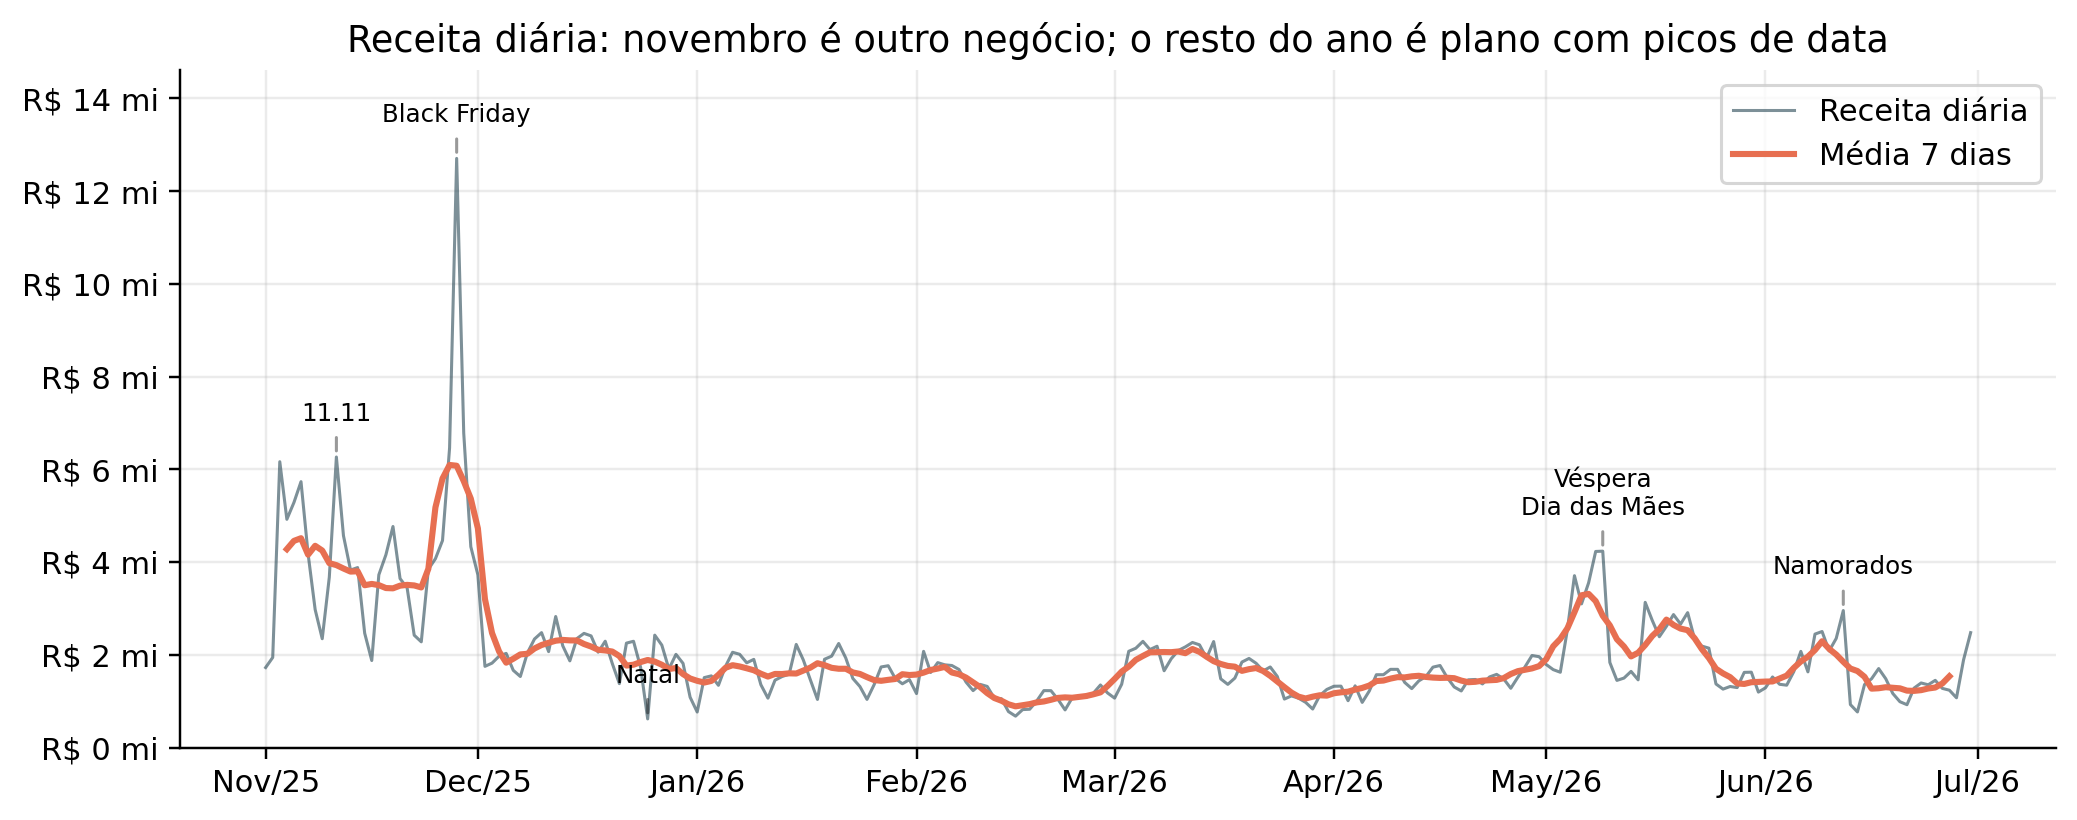

,evento,data,receita_mi,x_mediana_geral,x_media_mes
0,11.11,2025-11-11,6.27,3.70,1.46
1,Black Friday,2025-11-28,12.71,7.51,2.96
2,Natal,2025-12-25,0.62,0.37,0.30
3,Véspera Dia das Mães,2026-05-09,4.24,2.50,1.87
4,Namorados,2026-06-12,2.96,1.75,1.87
5,Dia das Mães,2026-05-10,1.84,1.09,0.81


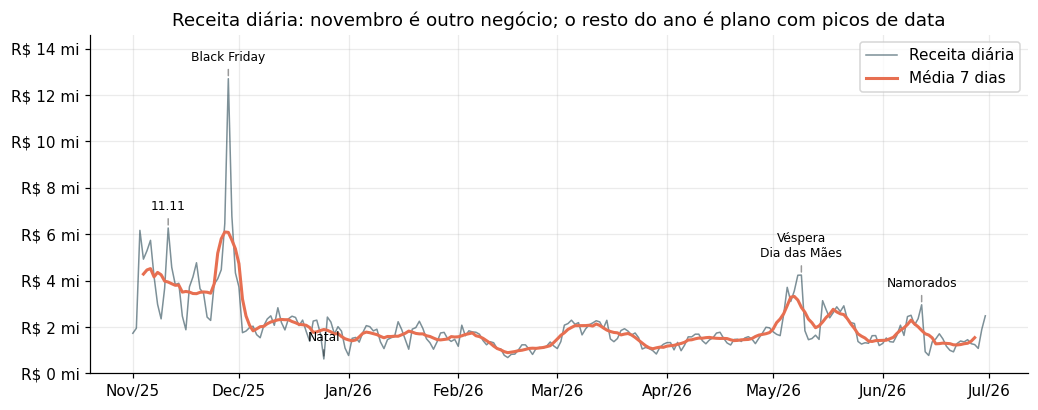

In [4]:
eda.fig_serie_diaria(g); display(Image("reports/figures/eda_01_serie_diaria.png"))
eda.eventos(g)

**Leitura**
- **Novembro é outro negócio**: 26% da receita e 34% dos pedidos dos 8 meses. Não é só a Black Friday (7,5× a mediana diária): 11.11 e vários dias de campanha passam de 3×.
- **Natal não tem pico** no e-commerce: 25/12 é o pior dia da base. A compra de Natal acontece antes (e provavelmente na loja física).
- **Dia das Mães tem pico na véspera** (sábado 09/05), não no domingo. Dia dos Namorados: 1,9× a média de junho.
- Fora dos eventos, a série é praticamente plana: **não há tendência forte para extrapolar**.

## 3. Potencial por dia da semana

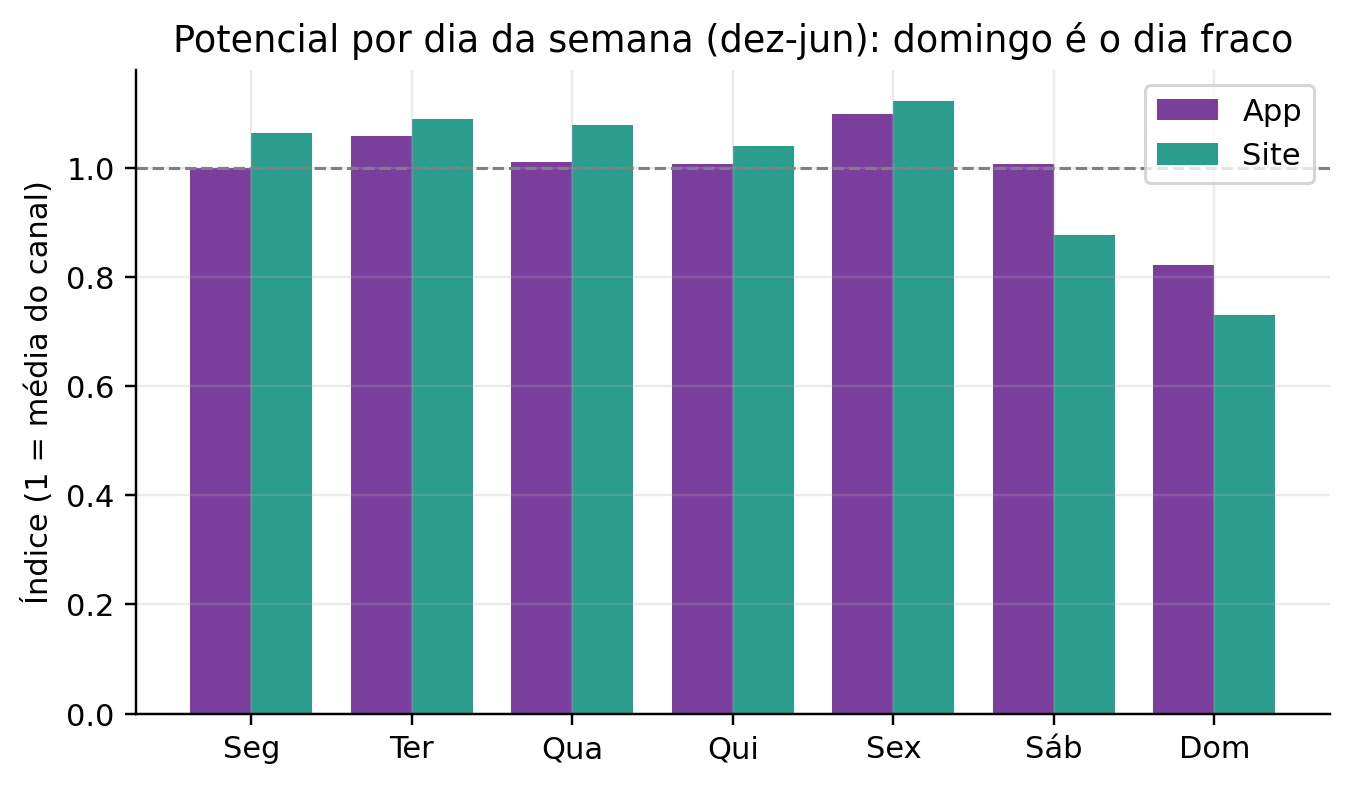

canal,App,Site
dia_semana,,
0,1.00,1.06
1,1.06,1.09
2,1.01,1.08
3,1.01,1.04
4,1.10,1.12
5,1.01,0.88
6,0.82,0.73


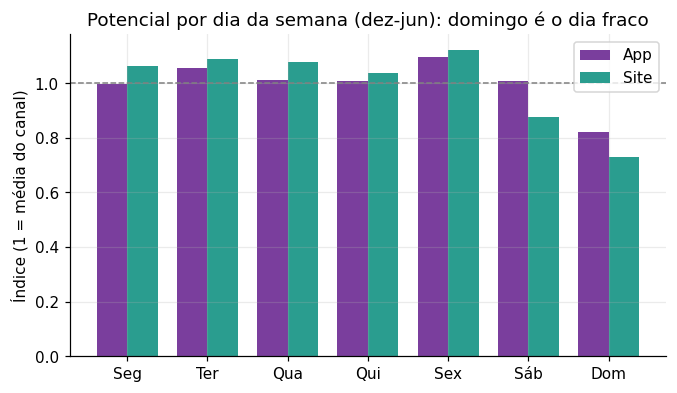

In [5]:
eda.fig_dia_semana(g); display(Image("reports/figures/eda_02_dia_semana.png"))
eda.indice_dia_semana(g)

**Leitura** (dez-jun, sem a distorção de novembro)
- **Sexta é o melhor dia** nos dois canais; **domingo, o pior** (App −18%, Site −27%).
- **O App segura o fim de semana**: sábado do App está na média; o do Site cai 12%. Comunicação de fim de semana rende mais no App.

## 4. Flutuação ao longo do dia

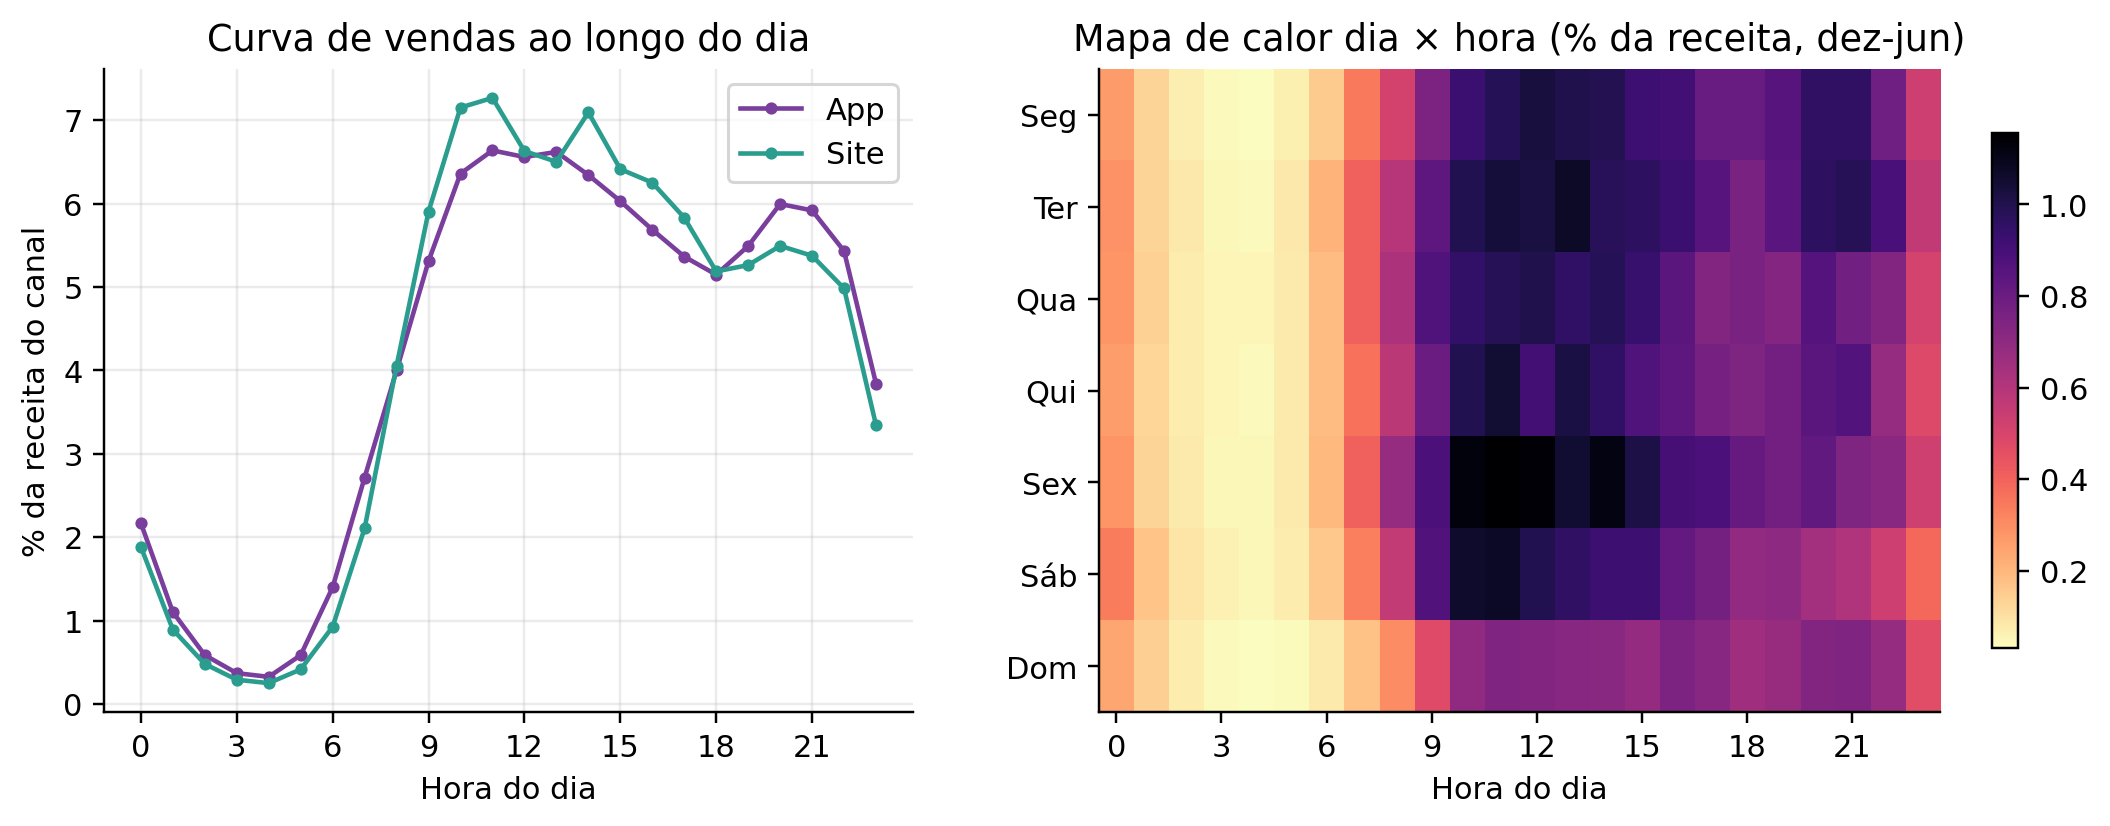

hora,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
canal,,,,,,,,,,,,,,,,,,,,,
App,2.17,1.10,0.59,0.37,0.33,0.59,1.40,2.72,4.00,5.31,...,6.34,6.03,5.69,5.36,5.15,5.49,6.00,5.92,5.43,3.84
Site,1.89,0.89,0.48,0.29,0.25,0.42,0.93,2.11,4.05,5.90,...,7.09,6.41,6.25,5.83,5.19,5.26,5.49,5.37,4.98,3.34


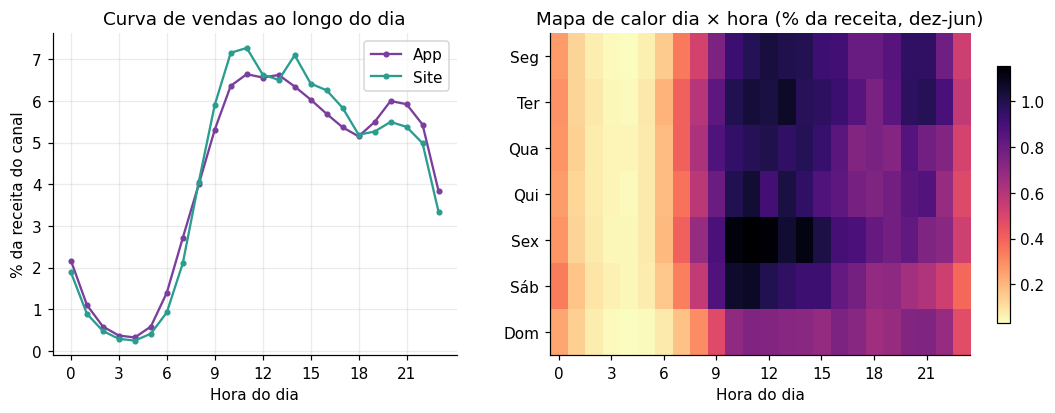

In [6]:
eda.fig_intradia(g); display(Image("reports/figures/eda_03_intradia.png"))
(eda.curva_intradia(g) * 100).T

**Leitura**
- Os dois canais **acordam juntos** (vale de 3h a 5h, subida a partir das 7h) e **atingem o pico às 11h**.
- **O App tem um segundo pico às 20h-21h**, mais forte que o do Site: é o canal do "sofá". Hipótese do handoff (Site 12-14h, App 21-22h) só parcialmente confirmada.
- O mapa de calor mostra a **sexta de manhã** como o horário mais quente da semana, e o domingo frio o dia todo.
- Uso prático: horário de disparo de push/CRM e de troca de banner.

## 5. Preço médio, ticket e desconto

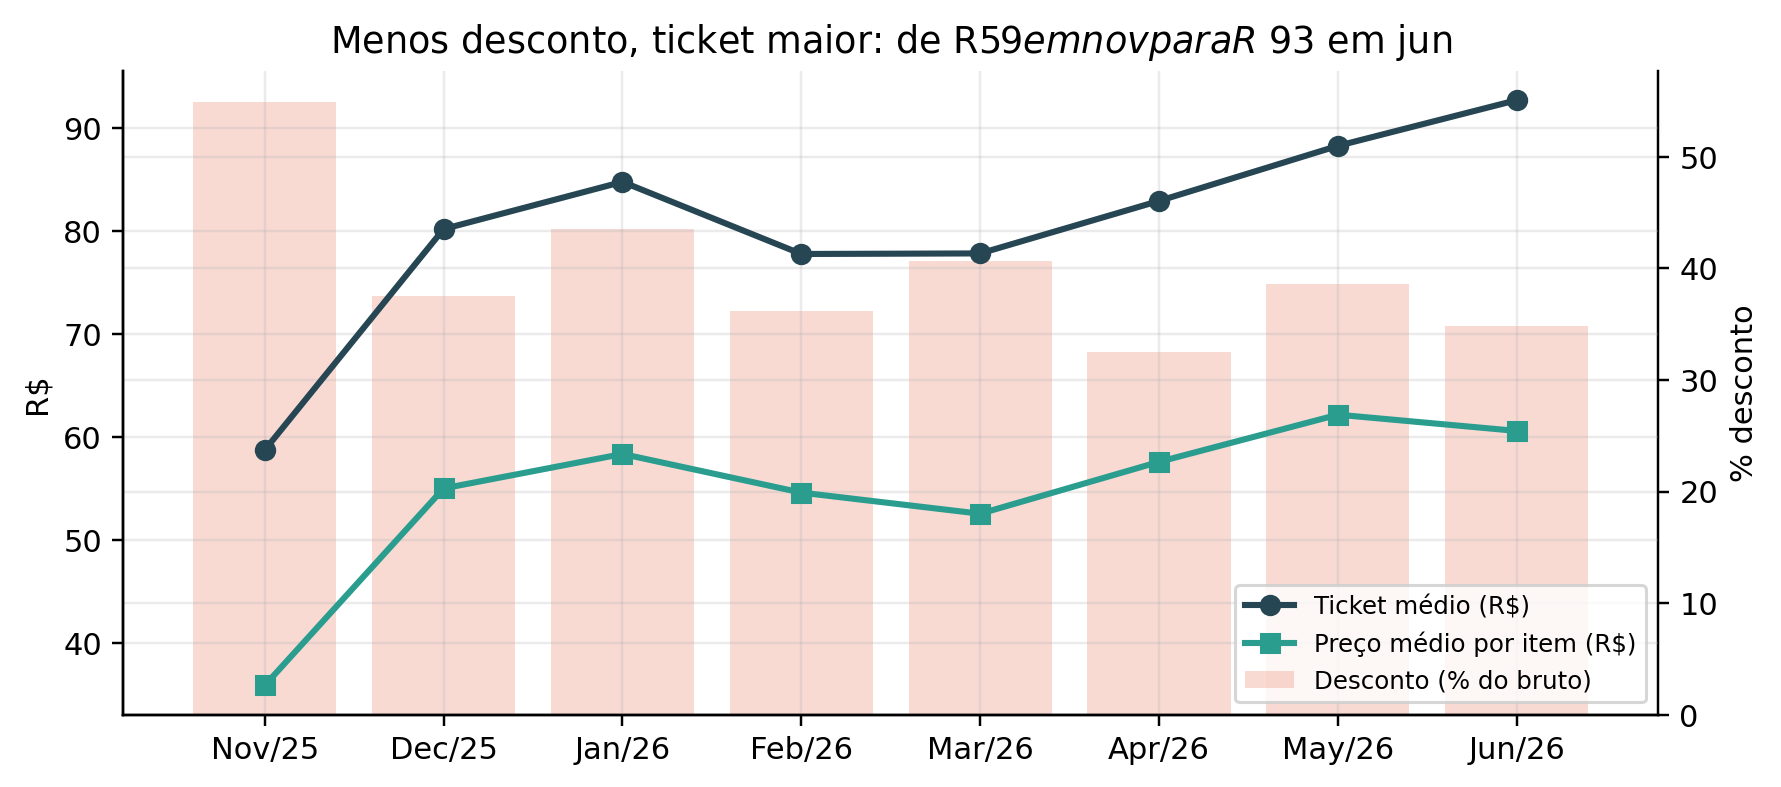

,ticket_medio,preco_medio,itens_por_pedido,taxa_desconto,estorno_pct
mes,,,,,
2025-11,58.76,35.89,1.64,0.55,0.05
2025-12,80.23,55.02,1.46,0.38,0.04
2026-01,84.81,58.37,1.45,0.44,0.04
2026-02,77.80,54.61,1.42,0.36,0.05
2026-03,77.86,52.56,1.48,0.41,0.04
2026-04,82.96,57.60,1.44,0.33,0.04
2026-05,88.31,62.19,1.42,0.39,0.04
2026-06,92.75,60.61,1.53,0.35,0.04


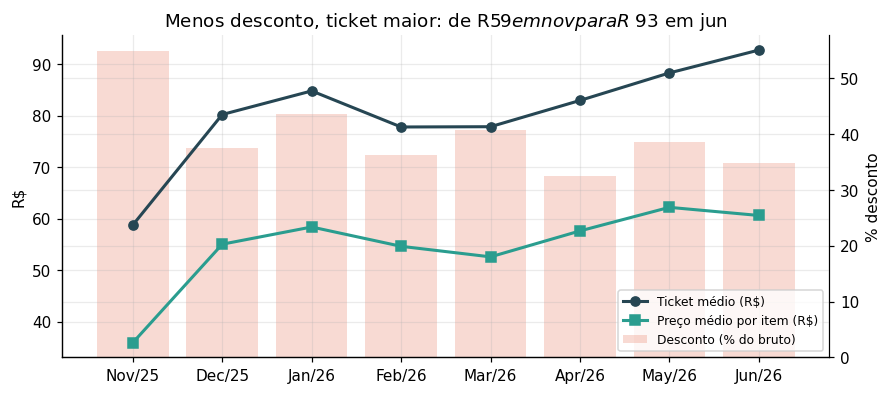

In [7]:
eda.fig_preco_desconto(g); display(Image("reports/figures/eda_04_preco_desconto.png"))
eda.mensal(g)[["ticket_medio", "preco_medio", "itens_por_pedido", "taxa_desconto", "estorno_pct"]]

**Leitura**
- **Ticket médio sobe de R$ 59 (nov) para R$ 93 (jun)** enquanto o desconto cai de 55% para 35% do preço cheio. Itens por pedido ficam estáveis (~1,5): **o ganho vem de preço por item, não de cesta maior**.
- Novembro compra volume com desconto; o resto do ano vende mais caro por pedido. Trade-off a discutir: quanto de receita futura a promoção antecipa?
- **Estornos estáveis em ~4% da receita todo mês**: não são efeito de evento, são estruturais (operação/logística). Vale investigação própria.
- Premissa: `taxa_desconto = desconto / (receita + desconto)`, assumindo receita líquida (D05).

## 6. Categoria × dia da semana

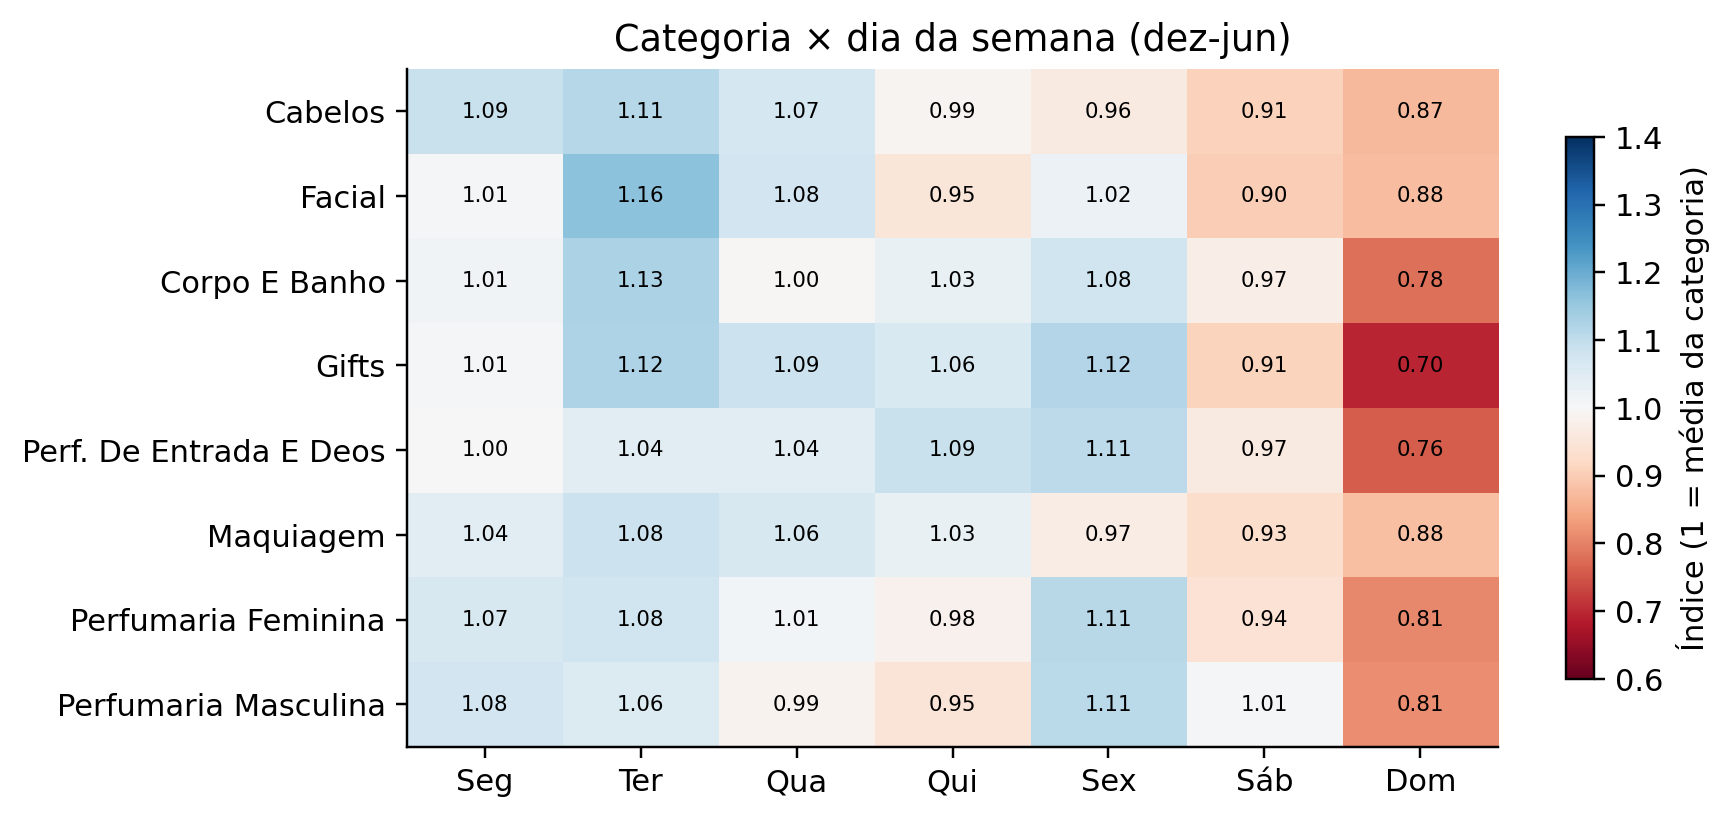

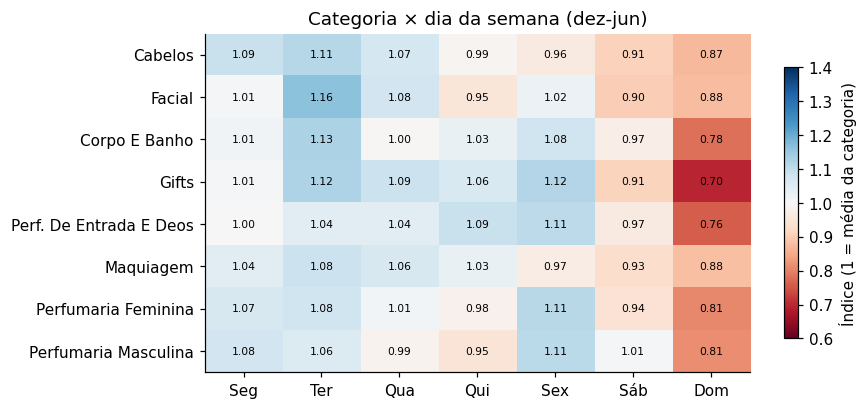

In [8]:
eda.fig_categoria_dia(g); display(Image("reports/figures/eda_05_categoria_dia.png"))

**Leitura**
- **Não existe "dia de categoria"**: todas seguem o mesmo padrão semanal (dias úteis fortes, domingo fraco). A hipótese do handoff (perfumaria qui/sex, maquiagem sáb) não se confirma.
- **Gifts é a mais sensível ao dia** (domingo −30%): compra de presente é planejada na semana.

## 7. Efeito payday

In [9]:
from scipy.stats import mannwhitneyu
d = to_daily(g); d = d[d["data"].dt.month != 11].copy()
eventos = pd.to_datetime(["2025-12-01", "2025-12-25", "2026-03-15", "2026-04-05", "2026-05-10", "2026-06-12"])
d = d[~d["data"].apply(lambda x: (abs((eventos - x).days) <= 3).any())]
d["dia_semana"], d["mes"] = d["data"].dt.dayofweek, d["data"].dt.to_period("M")
d["indice"] = d["receita"] / d.groupby(["mes", "dia_semana"])["receita"].transform("mean")
d["janela"] = pd.cut(d["data"].dt.day, [0, 4, 7, 19, 22, 31], labels=["1-4", "5-7 (salário)", "8-19", "20-22 (adiantamento)", "23-31"])
display(d.groupby("janela", observed=True)["indice"].agg(["mean", "count"]))
mannwhitneyu(d.loc[d["data"].dt.day.isin([5, 6, 7]), "indice"], d.loc[~d["data"].dt.day.isin([5, 6, 7]), "indice"])

,mean,count
janela,,
1-4,1.01,21
5-7 (salário),1.22,17
8-19,1.04,63
20-22 (adiantamento),1.00,20
23-31,0.88,52


MannwhitneyuResult(statistic=np.float64(2116.0), pvalue=np.float64(5.6716695352064784e-05))

**Leitura**
- Índice = receita do dia ÷ média do mesmo dia da semana no mesmo mês (controla calendário), sem novembro e sem datas especiais.
- **Dias 5 a 7 vendem ~22% acima do esperado; dias 20 a 22, neutros.** O salário move a venda; o adiantamento, não.
- Ressalva: pode haver campanha recorrente no início do mês; sem calendário de campanhas, não dá para separar. Virou feature (`is_payday_5`, D08).

## 8. Participação dos canais

In [10]:
eda.share_canal_mensal(g)

canal,App,Site
mes,,
2025-11,0.76,0.24
2025-12,0.72,0.28
2026-01,0.75,0.25
2026-02,0.75,0.25
2026-03,0.77,0.23
2026-04,0.78,0.22
2026-05,0.78,0.22
2026-06,0.79,0.21


**Leitura**: o **App sobe de 72% (dez) para 79% (jun)** da receita. O e-commerce está migrando para o App; o Site tem ticket ~10% maior e desconto menor.

## 9. Estrutura estatística da série (para a modelagem)

ADF (dez-jun):  p = 0.008  (H0: não estacionária)
KPSS (dez-jun): p = 0.100  (H0: estacionária)
Força da sazonalidade semanal: 0.26


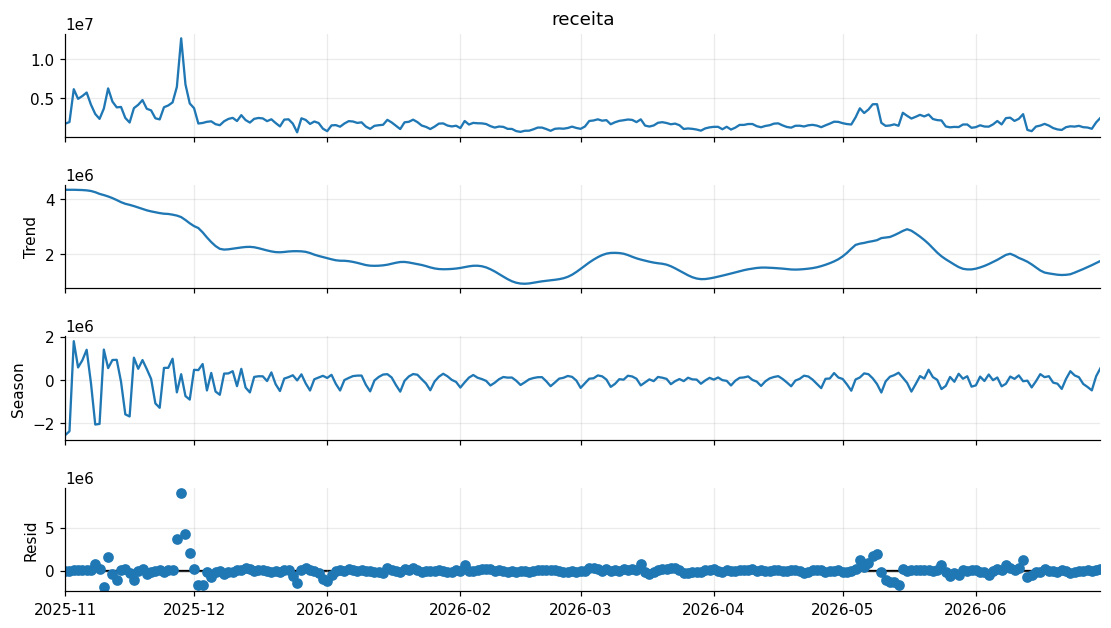

In [11]:
import warnings
warnings.simplefilter("ignore")
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
serie = to_daily(g).set_index("data")["receita"].asfreq("D")
stl = STL(serie, period=7, robust=True).fit()
fig = stl.plot(); fig.set_size_inches(11, 6); fig.savefig("reports/figures/eda_06_stl.png", bbox_inches="tight")
pos_nov = serie["2025-12-01":]
print(f"ADF (dez-jun):  p = {adfuller(pos_nov)[1]:.3f}  (H0: não estacionária)")
print(f"KPSS (dez-jun): p = {kpss(pos_nov, regression='c', nlags='auto')[1]:.3f}  (H0: estacionária)")
var = stl.seasonal.var() / (stl.seasonal.var() + stl.resid.var())
print(f"Força da sazonalidade semanal: {var:.2f}")

**Leitura**
- A decomposição separa tendência (dominada por novembro e Dia das Mães), sazonalidade semanal e resíduo (os eventos).
- **De dezembro a junho a série é estacionária** (ADF p = 0,008 rejeita raiz unitária; KPSS p ≥ 0,10 não rejeita estacionariedade): oscila em torno de um nível estável, sem tendência para extrapolar. Novembro é a quebra.
- **A sazonalidade semanal explica só ~26%** da variação não-tendencial; o resto são eventos e choques pontuais. Ou seja: **acertar os eventos importa mais do que acertar o dia da semana**. Isso favorece um modelo que combine calendário e eventos de forma não linear (árvores, D07) e alerta que a régua seasonal naive vai sofrer justamente nas datas especiais.

## Resumo para a apresentação

1. Novembro é um regime promocional à parte (26% da receita); o resto do ano é plano com picos de data.
2. Sexta é o melhor dia, domingo o pior; o App resiste melhor ao fim de semana.
3. Pico de vendas às 11h nos dois canais; o App tem um segundo pico noturno.
4. Menos desconto, ticket maior: R$ 59 → R$ 93, com itens por pedido estáveis.
5. Salário (dia 5) move a venda em ~22%; adiantamento (dia 20) não.
6. App avança de 72% para 79% da receita; estornos estruturais em ~4% ao mês.
7. Hipóteses do handoff descartadas pelo dado: pico de Natal, categoria por dia da semana, pico do Site às 12-14h.